In [1]:
import numpy as np
import matplotlib.pyplot as plt

1. plt.subplot(nrows, ncols, index) (Interfaz implícita / MATLAB)
Cómo funciona: Crea o selecciona un solo subgráfico (Axes) en la posición index (comienza en 1).

Manejo de estado: Modifica un estado global. Tienes que llamar a la función repetidamente pasando el índice para ir cambiando de cuadrícula.

Retorna: Un solo objeto Axes.

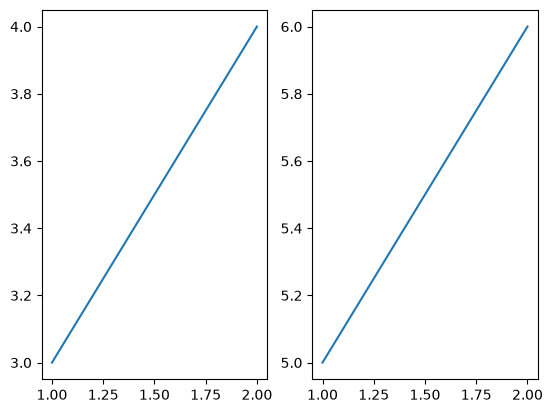

In [2]:
import matplotlib.pyplot as plt

# Hay que llamar la función para cada celda
plt.subplot(1, 2, 1)  # 1 fila, 2 columnas, posición 1
plt.plot([1, 2], [3, 4])

plt.subplot(1, 2, 2)  # 1 fila, 2 columnas, posición 2
plt.plot([1, 2], [5, 6])

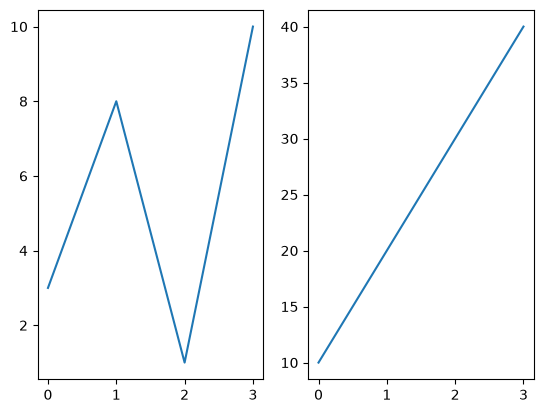

In [3]:
import matplotlib.pyplot as plt
import numpy as np

#plot 1:
x = np.array([0, 1, 2, 3])
y = np.array([3, 8, 1, 10])

plt.subplot(1, 2, 1)
plt.plot(x,y)

#plot 2:
x = np.array([0, 1, 2, 3])
y = np.array([10, 20, 30, 40])

plt.subplot(1, 2, 2)
plt.plot(x,y)

plt.show()

2. fig, ax = plt.subplots(nrows, ncols) (Interfaz Orientada a Objetos)

Cómo funciona: Crea la Figura completa y toda la cuadrícula de subgráficos en una sola línea.

Manejo de estado: Desacoplado del estado global. Retorna referencias explícitas a cada eje. Si $nrows \times ncols > 1$, ax es una matriz (array de NumPy) con todos los ejes.

Retorna: Una tupla (Figure, Axes).

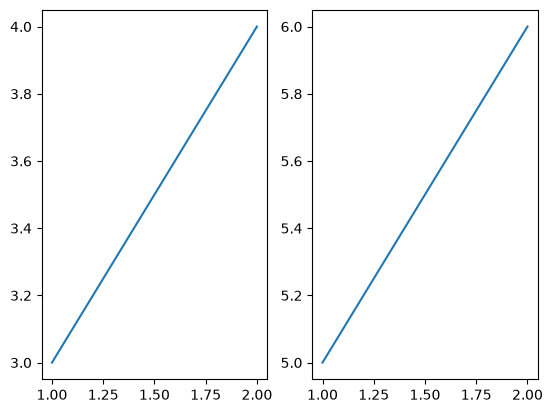

In [4]:
import matplotlib.pyplot as plt

# Crea todo de una vez y desempaqueta los ejes
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot([1, 2], [3, 4])
ax2.plot([1, 2], [5, 6])

La documentación oficial de Matplotlib recomienda usar el enfoque Orientado a Objetos con plt.subplots() para la mayoría de los casos. Evita depender de un estado global oculto, facilita la personalización de múltiples ejes y produce código más limpio y escalable.

Ambos sirven para el mismo objetivo final (organizar varios gráficos en una misma figura), pero no es recomendable usar el primero. La documentación oficial de Matplotlib recomienda explícitamente el segundo método (plt.subplots()) para casi cualquier proyecto.

¿Por qué NO se recomienda el primer método (plt.subplot)?
Redundancia: Te obliga a repetir las dimensiones de la cuadrícula (nrows, ncols) cada vez que quieres seleccionar una casilla.

Propenso a errores: Funciona mediante un "estado global activo". Matplotlib asume que las instrucciones siguientes aplican al último subplot seleccionado. Si tu código crece o cambias el orden de ejecución, es fácil terminar modificando el gráfico equivocado.

¿Por qué SÍ se recomienda el segundo método (plt.subplots)?
Definición limpia: Declaras la estructura completa de la figura en una sola línea.

Control explícito: Recibes variables directas para cada eje (ax1, ax2, etc. o una matriz ax[i, j]). Puedes modificar el contenido, título o límites de cualquier subgráfico en cualquier momento del código, sin importar cuál dibujaste primero.

In [ ]:
# ❌ Primer enfoque (Basado en estado - NO recomendado)
plt.subplot(2, 1, 1) # Redefines la cuadrícula (2, 1) y seleccionas el 1
plt.plot(x, y)
plt.title("Primero")

plt.subplot(2, 1, 2) # Redefines la cuadrícula (2, 1) y seleccionas el 2
plt.plot(x, z)
plt.title("Segundo")

# Si más adelante quieres modificar el primer gráfico,
# estás obligado a llamar de nuevo a plt.subplot(2, 1, 1)

In [ ]:
# ✅ Segundo enfoque (Orientado a Objetos - RECOMENDADO)
fig, (ax1, ax2) = plt.subplots(2, 1) # Declaras la estructura una sola vez

ax1.plot(x, y)
ax2.plot(x, z)

# Tienes acceso directo a cualquier eje cuando quieras
ax1.set_title("Primero")
ax2.set_title("Segundo")